# Práctica 1 - Visión por Computador
## Marcial Galván - Alejandra Rodríguez

### Tabla de contenidos
- [Tarea 1 - Tablero de ajedrez](#tarea-1---tablero-de-ajedrez)
    - [De forma manual](#de-forma-manual)
    - [Con inteligencia artificial](#con-inteligencia-artificial)
- [Tarea 2 - Arte al estilo de Mondrian](#tarea-2---arte-al-estilo-de-mondrian)
- [Tarea 3 - Detección de píxeles en vídeo](#tarea-3---detección-de-píxeles-en-vídeo)
- [Tarea 4 - Pop Art al estilo de Warhol](#tarea-4---pop-art-al-estilo-de-warhol)
- [Tarea Extra](#tarea-extra)

In [1]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt
import random

### Tarea 1 - Tablero de ajedrez

Crear una imagen de 800x800 píxeles con la textura del tablero de ajedrez.

In [2]:
width = 800
height = 800

#### De forma manual

En primer lugar, se crea la imagen programando manualmente (sin uso de inteligencias artificiales). En esta solución, se ha creado una clase `Chess`, que permite generar un tablero de ajedrez de dimensiones y cuadrícula personalizadas.
<br></br>
Usando el método `save`, se crea la imagen con el tablero y se muestra en pantalla a modo de _plot_:

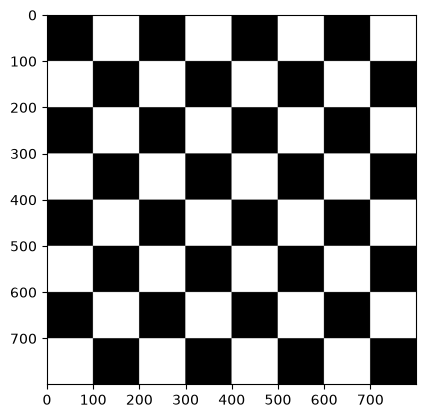

In [4]:
class Chess:
    def __init__(self, width=800, height=800, rows=8, cols=8):
        self.width = width
        self.height = height
        self.rows = rows
        self.cols = cols
        self.step_x= int((height)/rows)
        self.step_y= int((width)/cols)
        self.image = np.zeros((height,width, 1), dtype = np.uint8)
        self.__draw()
    
    def __get_color(self, x, y):
        return 255*((x+y)%2)
    
    def __draw(self):
        for y in range(self.rows):
            for x in range(self.cols):
                start_x, start_y = x*self.step_x, y*self.step_y
                self.image[start_x:(start_x + self.step_x), start_y:(start_y + self.step_y)] = self.__get_color(x, y)
    
    def plot(self):
        plt.imshow(self.image, cmap="gray") 
        plt.show()
    
    def save(self):
        cv2.imwrite('exercises/chess_manual.png', self.image)
        self.plot()

Chess().save()

#### Con inteligencia artificial

A continuación, con el ánimo de comparar los resultados generados con los implementados manualmente, se solicita a distintas inteligencias artificiales la resolución del mismo ejercicio.
<br></br>
El _prompt_ utilizado es: "*Make a chessboard 800x800, in black and white, with only 1 color canal (grey scale). Make it with matplotlib and pyplot. Save the image with cv2.imwrite in exercises/\<nombre_fichero>.png (assume the path exists) and plot it with plt.show. Return the necessary code.*"

Esta es la solución propuesta por Claude, utilizando `np.kron`:

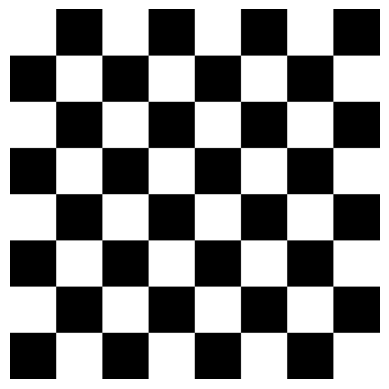

In [11]:
# Claude
size = 800
squares = 8
cell = size // squares  # 100 px per square

# 8x8 pattern: 255 (white) where row+col is even, 0 (black) otherwise
rows, cols = np.indices((squares, squares))
pattern = ((rows + cols) % 2 == 0).astype(np.uint8) * 255

# Scale each square up to 100x100 px -> 800x800, single channel (grayscale)
board = np.kron(pattern, np.ones((cell, cell), dtype=np.uint8))

# Save (2D uint8 array -> 1-channel PNG)
cv2.imwrite("exercises/chess_claude.png", board)

# Plot
plt.imshow(board, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
plt.show()

Esta es la solución propuesta por ChatGPT, usando `np.indices`:

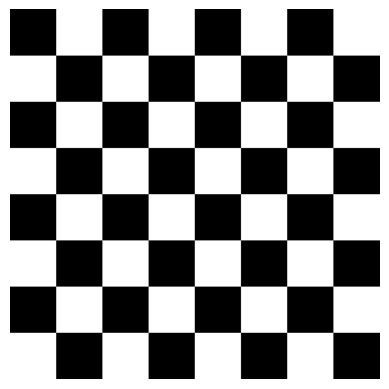

In [10]:
# ChatGPT
# Image dimensions
width = 800
height = 800
square_size = 100

# Generate row and column indices
rows, cols = np.indices((height, width))

# Create the chessboard pattern
chessboard = ((rows // square_size + cols // square_size) % 2) * 255

# Convert to uint8 for OpenCV
chessboard = chessboard.astype(np.uint8)

# Save as a single-channel grayscale image
cv2.imwrite("exercises/chess_chatgpt.png", chessboard)

# Display the image
plt.imshow(chessboard, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
plt.show()

Y, por último, esta es la solucion propuesta por Gemini, usando `np.tile` y `np.repeat`:

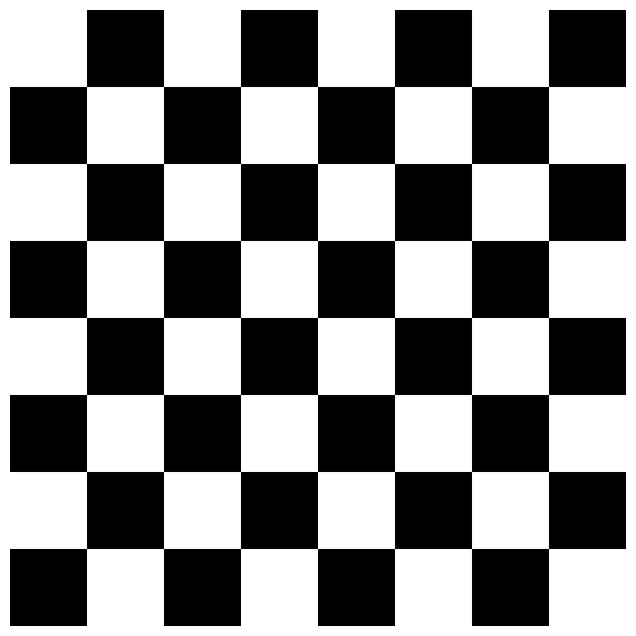

In [ ]:
# Gemini
# Create an 8x8 chessboard pattern with values 0 (black) and 255 (white)
square_size = 100
board_grid_size = 8

# Create a single 2x2 block of alternating squares
block = np.array([[255, 0], [0, 255]], dtype=np.uint8)

# Tile the block to create an 8x8 grid (800x800 pixels)
chessboard = np.tile(block, (board_grid_size // 2, board_grid_size // 2))
chessboard = np.repeat(np.repeat(chessboard, square_size, axis=0), square_size, axis=1)

# Save the single-channel grayscale image using OpenCV
cv2.imwrite("exercises/chess_gemini.png", chessboard)

# Display the chessboard using Matplotlib
plt.figure(figsize=(8, 8))
plt.imshow(chessboard, cmap="gray")
plt.axis("off")
plt.show()

### Tarea 2 - Arte al estilo de Mondrian

Crear una imagen [estilo Mondrian](https://www3.gobiernodecanarias.org/medusa/ecoescuela/sa/2017/04/17/descubriendo-a-mondrian/) con las funciones de dibujo de OpenCV.

In [77]:
width = 300
height = 200

Resolución de forma _naïve_, imitando manualmente la imagen propuesta como ejemplo:

In [78]:
def add_horizontal_lines():
    cv2.line(mondrian_img, (0, layers[0]), (width, layers[0]), line_color, 3)
    cv2.line(mondrian_img, (0, layers[1]), (x_step*16, layers[1]), line_color, 3)
    cv2.line(mondrian_img, (columns[0], layers[2]), (width, layers[2]), line_color, 3)

def add_vertical_lines():    
    cv2.line(mondrian_img, (columns[0], 0), ((columns[0], height)), line_color, 3)
    cv2.line(mondrian_img, (columns[1], 0), ((columns[1], height)), line_color, 3)
    cv2.line(mondrian_img, (columns[2], 0), ((columns[2], layers[1])), line_color, 3)
    cv2.line(mondrian_img, (columns[4], 0), ((columns[4], layers[2])), line_color, 3)
    cv2.line(mondrian_img, (columns[5], 0), ((columns[5], height)), line_color, 3)
    cv2.line(mondrian_img, (columns[3], layers[0]), (columns[3], height), line_color, 3)

def paint_rectangle():
    cv2.rectangle(mondrian_img, (columns[0],0), (columns[1], layers[0]),(255, 255, 0),-1)
    cv2.rectangle(mondrian_img, (columns[1],0), (columns[2], layers[0]),(0, 0, 255),-1)
    cv2.rectangle(mondrian_img, (columns[2],0), (columns[4], layers[0]),(255, 0, 0),-1)
    cv2.rectangle(mondrian_img, (columns[4],0), (columns[5], layers[0]),(255, 255, 0),-1)
    cv2.rectangle(mondrian_img, (columns[4],0), (columns[5], layers[0]),(255, 255, 0),-1)
    cv2.rectangle(mondrian_img, (columns[3],layers[0]),(columns[4],layers[1]),(0, 0, 255),-1)
    cv2.rectangle(mondrian_img, (columns[4],layers[0]),(columns[5],layers[1]),(255, 0, 0),-1)
    cv2.rectangle(mondrian_img, (columns[1],layers[1]),(columns[3],layers[2]),(255, 0, 0),-1)
    cv2.rectangle(mondrian_img, (columns[4],layers[1]),(columns[5],layers[2]),(255, 255, 0),-1)
    cv2.rectangle(mondrian_img, (columns[0],layers[2]),(columns[1],height),(0, 0, 255),-1)
    cv2.rectangle(mondrian_img, (columns[1],layers[2]),(columns[3],height),(255, 255, 0),-1)


line_color = (0, 0, 0)
x_step = int(width/17)
columns=[x_step, x_step*4, x_step*8, x_step*10, x_step*14, x_step*16]
layers=[int(height/3), int((height/3)*2), int((height/6)*5)]
mondrian_img = np.full((height,width,3), 255, dtype = np.uint8)

paint_rectangle()
add_horizontal_lines()
add_vertical_lines()

En forma de _plot_:

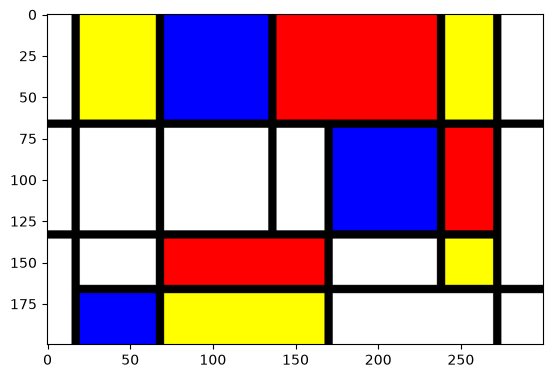

In [79]:
plt.imshow(mondrian_img) 
plt.show()

En forma de imagen:

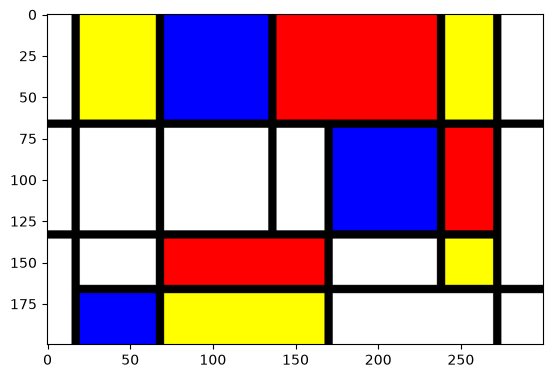

In [80]:
cv2.imwrite('exercises/mondrian_naive.png', cv2.cvtColor(mondrian_img, cv2.COLOR_BGR2RGB))
img = cv2.cvtColor(cv2.imread('exercises/mondrian_naive.png'), cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.show()

Resolución alternativa, generador aleatorio de composiciones mondrianas:

In [3]:
def paint_mondrian(width, height):
    color_img = np.full((height,width,3), 255, dtype = np.uint8)

    colors = [(255, 0, 0), (0, 0, 255), (255, 255, 0), (255, 255, 255), (255, 255, 255)]
    lines = [((0, 0), (width, 0)), ((0, 0), (0, height)), ((width-1, 0), (width-1, height)), ((0, height-1), (width, height-1))]

    y_coord = 0

    while y_coord < height:
        y_step = min(random.randint(height // 6, height // 2), height - y_coord)
        lines.append(((0, y_coord), (width, y_coord)))

        x_coord = 0
        while x_coord < width:
            x_step = min(random.randint(10, width // 2), width - x_coord)
            cv2.rectangle(color_img, (x_coord, y_coord), (x_coord + x_step, y_coord + y_step), random.choice(colors), -1)
            lines.append(((x_coord, y_coord), (x_coord, y_coord + y_step)))
            x_coord += x_step

        y_coord += y_step

    for line in lines:
        cv2.line(color_img, line[0], line[1], (0, 0, 0), 3)

    return color_img

En forma de _plot_:

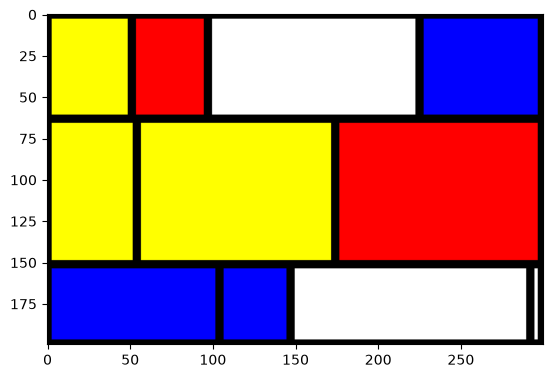

In [21]:
plt.imshow(paint_mondrian(width, height))
plt.show()

En forma de imagen:

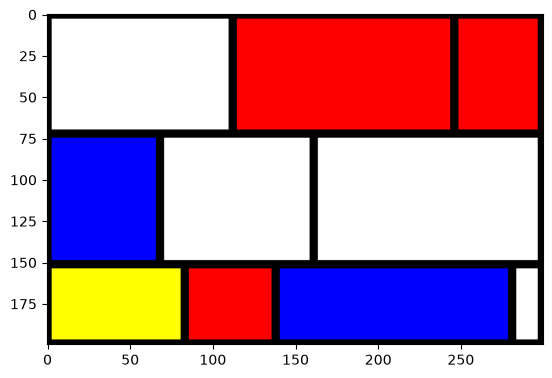

In [112]:
cv2.imwrite('exercises/mondrian_aleatorio.png', cv2.cvtColor(paint_mondrian(width, height), cv2.COLOR_BGR2RGB))
img = cv2.cvtColor(cv2.imread('exercises/mondrian_aleatorio.png'), cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.show()

### Tarea 3 - Detección de píxeles en vídeo

Pintar círculos en las posiciones del píxel más claro y oscuro de cada fotograma captado por la cámara.

En este caso, se ha elegido el color rojo para representar el píxel más claro, y el azul para mostrar el píxel más oscuro.
<br>
El resultado parece bastante fluido, no se aprecian tirones:

In [49]:
vid = cv2.VideoCapture(0)

while(True):
    ret, frame = vid.read()

    if ret:
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        _, _, min_loc, max_loc = cv2.minMaxLoc(gray)
        cv2.circle(frame, min_loc, 10, (255, 0, 0), 2)
        cv2.circle(frame, max_loc, 10, (0, 0, 255), 2)

        cv2.imshow('Tarea3', frame)

    if cv2.waitKey(20) == 27:
        break

vid.release()
cv2.destroyAllWindows()

### Tarea 4 - Pop Art al estilo de Warhol

Llevar a cabo una propuesta propia de Pop Art.

Para ello, se ha creado la función `get_warhol_transform()`, que devuelve una transformación de canal de color aleatoria:

In [ ]:
def get_warhol_transform():
    transforms = [
        lambda r, g, b: r.astype(np.int16) - g.astype(np.int16),
        lambda r, g, b: r.astype(np.int16) - b.astype(np.int16),
        lambda r, g, b: 255 - r,
        lambda r, g, b: r.astype(np.uint16) + g.astype(np.uint16),
        lambda r, g, b: r.astype(np.uint16) + b.astype(np.uint16),
        lambda r, g, b: b.astype(np.int16) - g.astype(np.int16),
        lambda r, g, b: b.astype(np.int16) - r.astype(np.int16),
        lambda r, g, b: 255 - b,
        lambda r, g, b: b.astype(np.uint16) + g.astype(np.uint16),
        lambda r, g, b: g.astype(np.int16) - b.astype(np.int16),
        lambda r, g, b: g.astype(np.int16) - r.astype(np.int16),
        lambda r, g, b: 255 - g,
        lambda r, g, b: r,
        lambda r, g, b: g,
        lambda r, g, b: b,
    ]
    return random.choice(transforms), random.choice(transforms), random.choice(transforms)

Esta función se ha utilizado para generar distintas combinaciones de Pop Art.
<br></br>
En esta composición, se genera un collage de tamaño 3x3, en el que cada sub-imagen utiliza una combinación de planos diferente y aleatoria.
<br></br>
Para cambiar las funciones transformadoras en ejecución, se puede pulsar la tecla `r`.

In [ ]:
vid = cv2.VideoCapture(0)

w = int(vid.get(cv2.CAP_PROP_FRAME_WIDTH)) // 3
h = int(vid.get(cv2.CAP_PROP_FRAME_HEIGHT)) // 3

warhol_transforms = [get_warhol_transform() for _ in range(9)]
collage = np.zeros((h * 3, w * 3, 3), dtype=np.uint8)

while True:
    ret, frame = vid.read()
    
    if ret:
        frame = cv2.resize(frame, (w, h), interpolation=cv2.INTER_NEAREST)
        b, g, r = frame[:, :, 0], frame[:, :, 1], frame[:, :, 2]

        for i in range(9):
            b_func, g_func, r_func = warhol_transforms[i]
            row, col = i // 3, i % 3

            collage[row * h : (row + 1) * h, col * w : (col + 1) * w] = cv2.merge(
                [np.clip(b_func(r, g, b), 0, 255).astype(np.uint8), 
                 np.clip(g_func(r, g, b), 0, 255).astype(np.uint8), 
                 np.clip(r_func(r, g, b), 0, 255).astype(np.uint8)]
            )

        cv2.imshow("Tarea4", collage)

        key = cv2.waitKey(20)
        if key == 27:
            break
        elif key == 114: # r = cambiar funciones
            warhol_transforms = [get_warhol_transform() for _ in range(9)]

vid.release()
cv2.destroyAllWindows()

### Tarea Extra
<br>
Haciendo uso de los conceptos aprendidos en las tareas 1-4, hemos realizado como tarea extra una herramienta de comparación entre color y detección de bordes.

In [13]:
def mouse_events(event, x, y, flags, param):
    if event == cv2.EVENT_MOUSEMOVE:
        global px, py
        px, py = x, y

In [ ]:
vid = cv2.VideoCapture(0)
running = False
px, py = -1, -1

while(True):
    ret, frame = vid.read()
    if ret:
        if not running:
            cv2.imshow('TareaExtra', frame)
            cv2.setMouseCallback('TareaExtra', mouse_events)
            running = True
        
        borders = cv2.cvtColor(cv2.Canny(frame, 75, 150), cv2.COLOR_GRAY2BGR)
    
        if px != -1 and py != -1:
            mask = np.zeros(frame.shape[:2], dtype=np.uint8)
            cv2.circle(mask, (px, py), 100, (255, 255, 255), -1)
            borders[mask > 0] = frame[mask > 0]
        
        cv2.imshow('TareaExtra', borders)
        
    if cv2.waitKey(20) == 27:
        break
  
vid.release()
cv2.destroyAllWindows()